In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from os.path import join
from os import makedirs
import shutil
from matplotlib.ticker import FuncFormatter
finetuning_results_file = "results/finetuning/summary/metrics.csv"

finetuning_df = pd.read_csv(finetuning_results_file)
print(finetuning_df.shape)

(42, 16)


In [2]:
# plot params

# uncomment below for latex-style plots
# plt.rcParams["text.usetex"] = True
# plt.rc('text', usetex=True)
# plt.rc('font', family='serif')

label_font_size = 20
legend_font_size = 16
tick_font_size = 18
text_marker_font_size = 14


line_width = 2
marker_size = 9
# marker_styles = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', '*']

plot_folder = "plots"

file_ext1 = ".png"
file_ext2 = ".pdf"

In [3]:
def is_float(s):
    try:
        float(s)
        return True
    except ValueError:
        return False
    
def extract_info(run_name):
    # splits the autrainer-specific coding for runnames from 
    # a single string into a tuple
    run_split = run_name.split("_")
    dataset_name = run_split[0]
    dataset_name = dataset_name.split("-")[0]
    
    model = run_split[1]
    # remove "grayscale" coding
    model = model.replace("-gray", "")
    
    model_info_split = model.split("-")
    model_info = model_info_split[1:]
    
    # no pre-training 
    if len(model_info) == 0:
        data_percentage = 0.
        pretrain_data = "None"
    # with pre-training
    else:
        pretrain_data = model_info[0]
        
        # default for ontology-based subsets
        data_percentage = 1.
        # random fraction-subsets
        if is_float(model_info[1]):
            data_percentage = float(model_info[1])    
        
        elif model_info[1][0] not in ("P", "E") and pretrain_data == "AS":
            pretrain_data = "-".join((pretrain_data, model_info[1]))
    return dataset_name, pretrain_data, data_percentage


In [4]:
dfs = []
for _, row in finetuning_df.iterrows():
    dataset_name, pretrain_data, data_percentage = extract_info(row['run_name'])
    row['dataset'] = dataset_name
    #row['model_type'] = model_type
    row['pretrain_data'] = pretrain_data
    row['data_percentage'] = data_percentage
    dfs.append(row)

result_df = pd.DataFrame(dfs)
print(result_df.shape)

(42, 19)


In [5]:
# reduce to epoch experiments

models = ["Cnn10"]
datasets = result_df["dataset"].unique()

AS_subset_sizes = {
    "AS": 1716492, 
    "AS-things": 246927, 
    "AS-speech": 836623, 
    "AS-humansounds": 910601, 
    "AS-naturalsources": 981575, 
    "AS-nature": 110144,
    "AS-nonhuman": 344532,
    "AS-naturalsounds": 31310,
    "AS-animal": 81237,
    "None": 0.0
}

AS_subset_classes = {
    "AS": 527, 
    "AS-things": 167, 
    "AS-speech": 8, 
    "AS-humansounds": 72, 
    "AS-naturalsources": 154, 
    "AS-nature": 82,
    "AS-nonhuman": 256,
    "AS-naturalsounds": 18,
    "AS-animal": 65,
    "None": 0
}

result_df['pretrain_full_datasize'] = result_df['pretrain_data'].map(AS_subset_sizes)
result_df['pretrain_datasize'] = result_df['pretrain_full_datasize'] * result_df['data_percentage'] 
result_df['pretrain_classes'] = result_df['pretrain_data'].map(AS_subset_classes)
#results_df.to_csv(join(subsets_folder, "subsets.csv"))
print(result_df.shape)
result_df

(42, 22)


,run_name,accuracy,uar,f1,train_loss,dev_loss,accuracy.std,uar.std,f1.std,train_loss.std,...,test_accuracy,test_uar,test_f1,test_loss,dataset,pretrain_data,data_percentage,pretrain_full_datasize,pretrain_datasize,pretrain_classes
0,DCASE2018Task3-16k_Cnn10-AS-0.01-P_Adam_0.001_...,0.909354,0.906818,0.907349,0.226751,0.258945,0.003483,0.003154,0.003371,0.001649,...,0.761292,0.808014,0.733886,0.565375,DCASE2018Task3,AS,0.01,1716492.0,17164.92,527
1,DCASE2018Task3-16k_Cnn10-AS-0.03-P_Adam_0.001_...,0.909354,0.906702,0.907309,0.228265,0.250401,0.002011,0.003282,0.002426,0.003099,...,0.797625,0.816886,0.763871,0.506723,DCASE2018Task3,AS,0.03,1716492.0,51494.76,527
2,DCASE2018Task3-16k_Cnn10-AS-0.1-P_Adam_0.001_3...,0.913446,0.910729,0.911479,0.187025,0.251959,0.000752,0.001940,0.001111,0.003376,...,0.813917,0.814861,0.774792,0.459036,DCASE2018Task3,AS,0.10,1716492.0,171649.20,527
3,DCASE2018Task3-16k_Cnn10-AS-0.3-P_Adam_0.001_3...,0.915974,0.913461,0.914097,0.234093,0.238581,0.000417,0.000399,0.000127,0.001779,...,0.818292,0.827677,0.782695,0.432995,DCASE2018Task3,AS,0.30,1716492.0,514947.60,527
4,DCASE2018Task3-16k_Cnn10-AS-P_Adam_0.001_32_ep...,0.916817,0.913987,0.914899,0.179739,0.246710,0.002758,0.001225,0.002295,0.001948,...,0.834833,0.837469,0.799014,0.434391,DCASE2018Task3,AS,1.00,1716492.0,1716492.00,527
5,DCASE2018Task3-16k_Cnn10-AS-animal-P_Adam_0.00...,0.911159,0.909167,0.909285,0.270728,0.252024,0.002255,0.002208,0.002343,0.000838,...,0.800208,0.820730,0.766652,0.486603,DCASE2018Task3,AS-animal,1.00,81237.0,81237.00,65
6,DCASE2018Task3-16k_Cnn10-AS-humansounds-P_Adam...,0.914169,0.911099,0.912163,0.173367,0.259766,0.003962,0.002298,0.003470,0.003258,...,0.793125,0.818811,0.761371,0.878970,DCASE2018Task3,AS-humansounds,1.00,910601.0,910601.00,72
7,DCASE2018Task3-16k_Cnn10-AS-naturalsounds-P_Ad...,0.909835,0.908309,0.908020,0.194872,0.271011,0.006554,0.005081,0.006587,0.001373,...,0.793875,0.817866,0.760923,0.509086,DCASE2018Task3,AS-naturalsounds,1.00,31310.0,31310.00,18
8,DCASE2018Task3-16k_Cnn10-AS-naturalsources-P_A...,0.917660,0.915370,0.915848,0.230772,0.240053,0.001251,0.001439,0.001065,0.002195,...,0.834125,0.839827,0.799095,0.465904,DCASE2018Task3,AS-naturalsources,1.00,981575.0,981575.00,154
9,DCASE2018Task3-16k_Cnn10-AS-nature-P_Adam_0.00...,0.912122,0.910447,0.910331,0.246002,0.248690,0.003978,0.002285,0.003464,0.001564,...,0.769958,0.810750,0.741379,0.714238,DCASE2018Task3,AS-nature,1.00,110144.0,110144.00,82


<>:62: SyntaxWarning: invalid escape sequence '\#'
<>:62: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_85764/687694564.py:62: SyntaxWarning: invalid escape sequence '\#'
  plt.xlabel("\# Classes", fontsize=label_font_size)


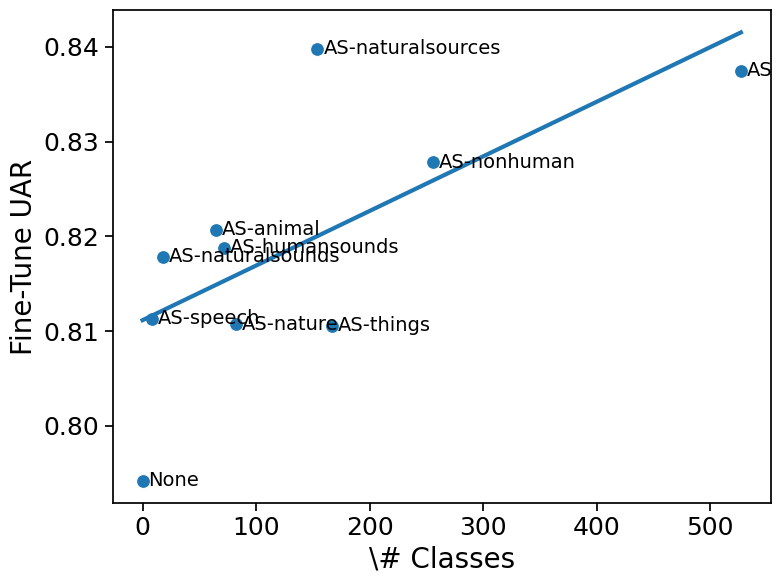

<Figure size 640x480 with 0 Axes>

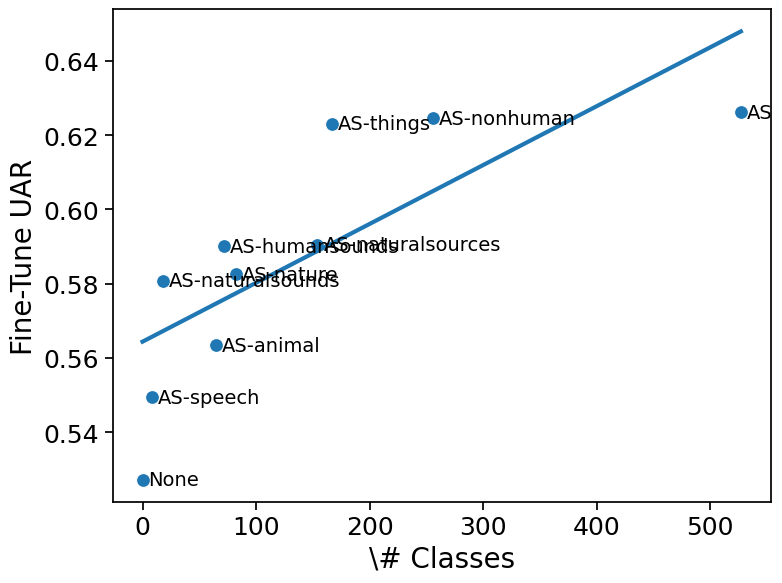

<Figure size 640x480 with 0 Axes>

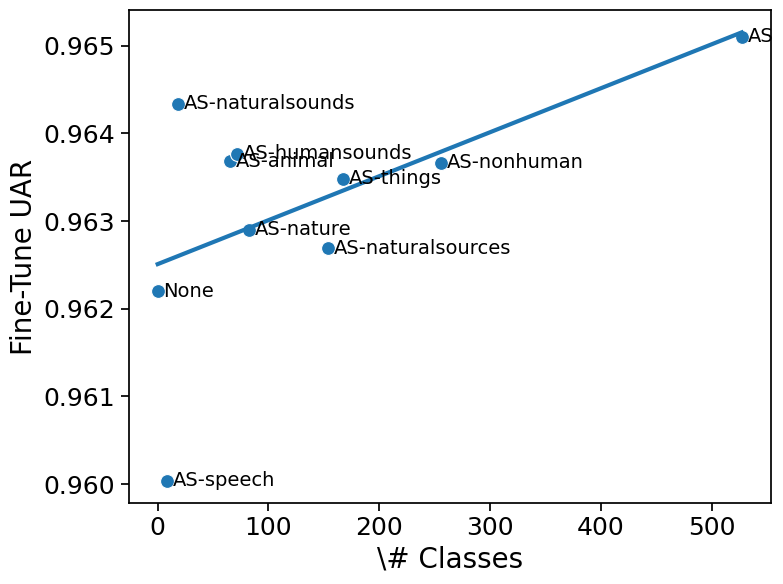

<Figure size 640x480 with 0 Axes>

In [6]:
# Calculate offsets based on axis ranges
subsets_classes_folder = join(plot_folder, "AS-sbusets_classes")
makedirs(subsets_classes_folder, exist_ok = True)

df_subsets = result_df
df_subsets_classes = df_subsets[df_subsets["data_percentage"].isin([1, 0])]
x_range = df_subsets_classes['pretrain_classes'].max() - df_subsets_classes['pretrain_classes'].min()
y_range = df_subsets_classes['test_uar'].max() - df_subsets_classes['test_uar'].min()
x_offset = x_range * 0.01  # 1% of x-axis range
y_offset = y_range * 0.01  # 1% of y-axis range


sns.set_context("notebook", 
                rc={
                  "lines.linewidth": line_width,   
                  "lines.markersize": marker_size   
                })

# uncomment for latex style plots
#plt.rcParams["text.usetex"] = True
#plt.rc('text', usetex=True)
#plt.rc('font', family='serif')

for dataset in df_subsets_classes['dataset'].unique():
    dataset_df = df_subsets_classes[df_subsets_classes['dataset'] == dataset]

    # Initialize a new plot for each dataset
    plt.figure(figsize=(8, 6))
    
    # Scatter plot: uniform color and marker
    sns.scatterplot(
        data=dataset_df,
        x='pretrain_classes',
        y='test_uar',
        color='tab:blue',
        marker='o',
        s=100 
    )

    # Regression line
    sns.regplot(
        data=dataset_df,
        x='pretrain_classes',
        y='test_uar',
        scatter=False,
        color='tab:blue',
        ci=None
        
    )

    # Add pretrain date annotations
    for idx, row in dataset_df.iterrows():
        plt.text(
            row['pretrain_classes'] + x_offset,
            row['test_uar'],
            row['pretrain_data'],
            fontsize=text_marker_font_size,
            verticalalignment='center'
        )

    # Set plot title and labels
    plt.xlabel("\# Classes", fontsize=label_font_size)
    plt.ylabel("Fine-Tune UAR", fontsize=label_font_size)
    plt.xticks(fontsize=tick_font_size)
    plt.yticks(fontsize=tick_font_size)

    # Save and show the plot
    subsets_classes_path = join(subsets_classes_folder, "subsets_classes_" + dataset)
    plt.tight_layout()
    plt.savefig(subsets_classes_path + file_ext1)
    plt.savefig(subsets_classes_path + file_ext2)
    plt.show()
    plt.clf()

<>:81: SyntaxWarning: invalid escape sequence '\#'
<>:81: SyntaxWarning: invalid escape sequence '\#'
/tmp/ipykernel_85764/2619762410.py:81: SyntaxWarning: invalid escape sequence '\#'
  plt.xlabel("\# Samples", fontsize=label_font_size)


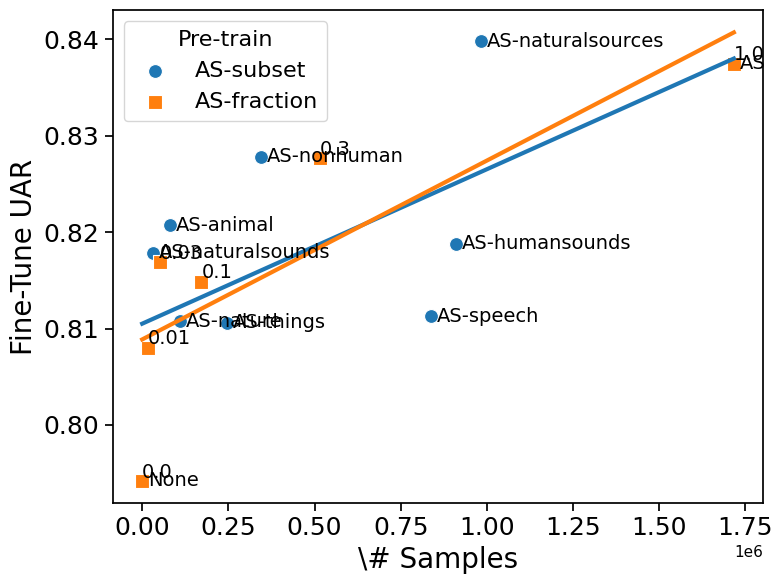

<Figure size 640x480 with 0 Axes>

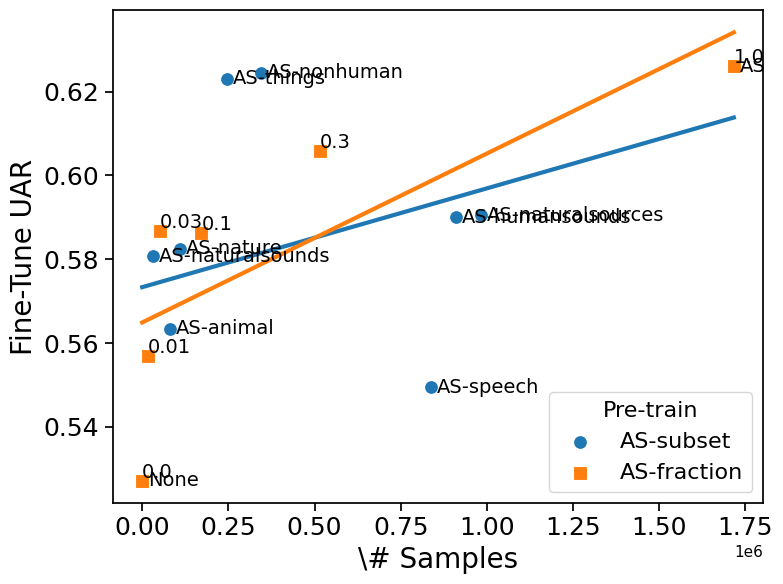

<Figure size 640x480 with 0 Axes>

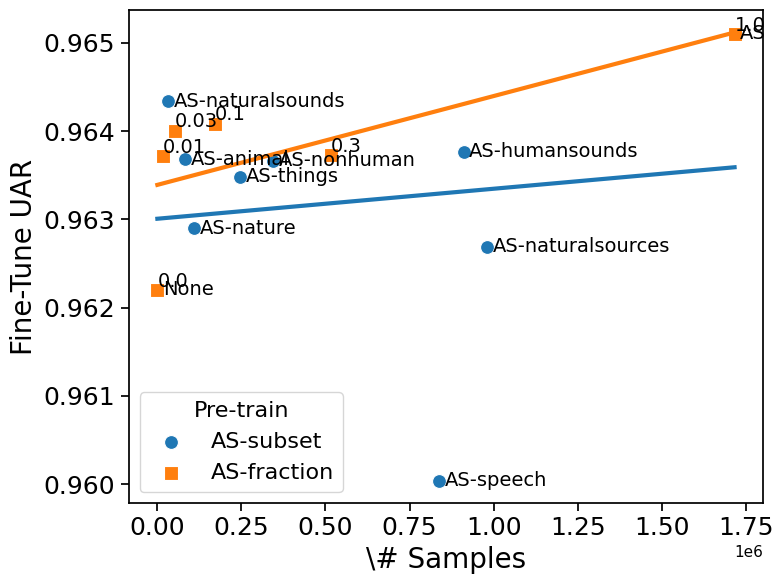

<Figure size 640x480 with 0 Axes>

In [7]:
subsets_samples_folder = join(plot_folder, "AS-subset_samples")
makedirs(subsets_samples_folder, exist_ok = True)

# Plot each dataset individually in separate plots
for dataset in df_subsets['dataset'].unique():
    dataset_df = df_subsets[df_subsets['dataset'] == dataset]
    df_ontology = dataset_df[dataset_df["data_percentage"].isin([1, 0])]
    df_fraction = dataset_df[dataset_df["pretrain_data"].isin(["AS", "None"])]
    
    x_range = dataset_df['pretrain_datasize'].max() - df_subsets['pretrain_datasize'].min()
    y_range = dataset_df['test_uar'].max() - dataset_df['test_uar'].min()
    
    x_offset = x_range * 0.01  # 1% of x-axis range
    y_offset = y_range * 0.02  # 2% of y-axis range
    plt.figure(figsize=(8, 6))
    sns.set_context("notebook", 
                rc={
                  "lines.linewidth": line_width,    
                  "lines.markersize": marker_size  
                })
    # uncomment for latex style plots
    #plt.rcParams["text.usetex"] = True
    #plt.rc('text', usetex=True)
    #plt.rc('font', family='serif')
    
    # Scatter and regplot for df_ontology
    sns.scatterplot(
        data=df_ontology,
        x='pretrain_datasize',
        y='test_uar',
        color='tab:blue',
        marker='o',
        s=100,
        label="AS-subset"
    )
    sns.regplot(
        data=df_ontology,
        x='pretrain_datasize',
        y='test_uar',
        scatter=False,
        ci=None,
        color='tab:blue'
    )
    for idx, row in df_ontology.iterrows():
        plt.text(
            row['pretrain_datasize'] + x_offset,
            row['test_uar'],
            row['pretrain_data'],
            fontsize=text_marker_font_size,
            verticalalignment='center'
        )

    # Scatter and regplot for df_fraction
    sns.scatterplot(
        data=df_fraction,
        x='pretrain_datasize',
        y='test_uar',
        color='tab:orange',
        marker='s',
        s=100,
        label="AS-fraction"
    )
    sns.regplot(
        data=df_fraction,
        x='pretrain_datasize',
        y='test_uar',
        scatter=False,
        color='tab:orange',
        ci=None
    )
    for idx, row in df_fraction.iterrows():
        plt.text(
            row['pretrain_datasize'],
            row['test_uar'] + y_offset,
            str(row['data_percentage']),
            fontsize=text_marker_font_size,
            verticalalignment='center'
        )

    # Set plot labels
    plt.xlabel("\# Samples", fontsize=label_font_size)
    plt.ylabel("Fine-Tune UAR", fontsize=label_font_size)
    plt.xticks(fontsize=tick_font_size)
    plt.yticks(fontsize=tick_font_size)
    plt.legend(title="Pre-train", fontsize=legend_font_size, title_fontsize=legend_font_size)

    # Save and show
    subsets_samples_path = join(subsets_samples_folder, "subsets_samples_" + dataset)
    plt.tight_layout()
    plt.savefig(subsets_samples_path + file_ext1)
    plt.savefig(subsets_samples_path + file_ext2)
    plt.show()
    plt.clf()